In [2]:
#this code with reload any imports if you're updating them actively
%reload_ext autoreload
%autoreload 2
#import scipy.obinimize as obin
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
#PyGEM
import pygem_eb.input as eb_prms
import pygem.pygem_input as pygem_prms
import pygem.pygem_modelsetup as modelsetup
import class_climate

In [3]:
def initialize_model():
    if pygem_prms.glac_no not in ['01.00570'] and pygem_prms.run_eb:
        print('EB model can currently only run Gulkana glacier')
    glacier_table = modelsetup.selectglaciersrgitable(pygem_prms.glac_no,
                    rgi_regionsO1=pygem_prms.rgi_regionsO1, rgi_regionsO2=pygem_prms.rgi_regionsO2,
                    rgi_glac_number=pygem_prms.rgi_glac_number, include_landterm=pygem_prms.include_landterm,
                    include_laketerm=pygem_prms.include_laketerm, include_tidewater=pygem_prms.include_tidewater)
    # Automatically generate hourly (freq = 'h') dates
    startdate = eb_prms.startdate
    enddate = eb_prms.enddate
    dates_table = pd.DataFrame({'date' : pd.date_range(startdate, enddate, freq='h')})
    # Extract attributes for dates_table
    dates_table['year'] = dates_table['date'].dt.year
    dates_table['month'] = dates_table['date'].dt.month
    dates_table['day'] = dates_table['date'].dt.day
    dates_table['hour'] = dates_table['date'].dt.hour
    dates_table['daysinmonth'] = dates_table['date'].dt.daysinmonth
    dates_table['timestep'] = np.arange(len(dates_table['date']))
    # Set date as index
    dates_table.set_index('timestep', inplace=True)
    # Remove leap year days if user selected this with option_leapyear
    if pygem_prms.option_leapyear == 0:
        # First, change 'daysinmonth' number
        mask1 = dates_table['daysinmonth'] == 29
        dates_table.loc[mask1,'daysinmonth'] = 28
        # Next, remove the 29th days from the dates
        mask2 = ((dates_table['month'] == 2) & (dates_table['day'] == 29))
        dates_table.drop(dates_table[mask2].index, inplace=True)
        dates_table['timestep'] = np.arange(len(dates_table['date']))
        dates_table.set_index('timestep', inplace=True)

    # Add column for water year
    # Water year for northern hemisphere using USGS definition (October 1 - September 30th),
    # e.g., water year for 2000 is from October 1, 1999 - September 30, 2000
    dates_table['wateryear'] = dates_table['year']
    for step in range(dates_table.shape[0]):
        if dates_table.loc[step,'month'] >= 10:
            dates_table.loc[step,'wateryear'] = dates_table.loc[step,'year'] + 1

    nyr = enddate.year-startdate.year

    return nyr

In [4]:
def plot_avgs(file,nyr,airtemp):
    """
    Plots heat fluxes, surface/air temperature, and mass balance terms, averaged monthly and then interannually.
    """
    months = np.arange(1,13)

    fig,axes = plt.subplots(3,3,sharex=True,sharey='row',figsize=(12,6))

    ds = xr.open_dataset(file)
    varnames_idx = ['SWin','SWout','LWin','LWout','sensible','latent','rain','meltenergy','surftemp','melt','runoff','refreeze','accum']
    varnames = ['SWnet','LWnet','sensible','latent','rain','meltenergy','surftemp','melt','runoff','refreeze','accum']
    heat = ['SWnet','LWnet','sensible','latent','rain','meltenergy']
    temp = ['surftemp']
    mb = ['melt','runoff','refreeze','accum','MB']

    for bin_no in [0,1,2]:
        df = ds[varnames_idx].isel(bin=bin_no).to_pandas()
        df['SWnet'] = df['SWin'] + df['SWout']
        df['LWnet'] = df['LWin'] + df['LWout']
        
        for var in varnames:
            if var in ['melt','runoff','refreeze','accum','MB']:
                monthly = df[var].resample('M').sum()
            else:
                monthly = df[var].resample('M').mean()
            monthly_avg = np.mean(monthly[:(nyr*12)].values.reshape((nyr,12)),axis=0)
            run_start_month = pd.Timestamp(ds.coords['time'].values[0]).month
            if run_start_month > 1:
                monthly_avg_jan = np.append(monthly_avg[13-run_start_month:],monthly_avg[:13-run_start_month],)

            axis = np.piecewise(var,[var in heat, var in temp, var in mb],[0,1,2])
            lw = 1 if var in ['meltenergy','surftemp'] else 0.5
            axes[int(axis),bin_no].plot(months,monthly_avg_jan,label=var,linewidth=lw)
        axes[1,bin_no].plot(months,airtemp[bin_no,:],linewidth=0.5,label='air temp')
        axes[1,bin_no].axhline(0,lw=0.3,color='gray')
        axes[bin_no,2].set_xticks(months)
    axes[0,0].set_ylabel('Energy Flux ($W / m^2$)')
    axes[1,0].set_ylabel('Temperature (C)')
    axes[2,0].set_ylabel('Mass balance (m w.e.)')

    binname = ['Lower','Middle','Upper']
    for i in range(3):
        axes[0,i].set_title(binname[i])
    axes[0,0].legend(loc='upper right',bbox_to_anchor=(1.25, 1.0))
    axes[1,0].legend()
    axes[2,0].legend()
    fig.suptitle(f'Gulkana Glacier (ERA5-Hourly)\nMonthly Averages Over {nyr}-yr Run')
    fig.supxlabel('Months')
    #plt.gcf().autofmt_xdate()
    plt.show()

In [5]:
def plot_yrs(file,bin,nyr):
    months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
    fig,axes = plt.subplots(nyr,3,sharex=True,sharey='col',figsize=(14,8))

    ds = xr.open_dataset(file)
    varnames_idx = ['SWin','SWout','LWin','LWout','sensible','latent','rain','meltenergy','surftemp','melt','runoff','refreeze','accum','snowdepth']
    varnames = ['SWnet','LWnet','sensible','latent','rain','meltenergy','surftemp','melt','runoff','refreeze','accum','snowdepth']
    heat = ['SWnet','LWnet','sensible','latent','rain','meltenergy']
    temp = ['surftemp','snowdepth']
    mb = ['melt','runoff','refreeze','accum','MB']

    df = ds[varnames_idx].isel(bin=bin).to_pandas()
    df['SWnet'] = df['SWin'] + df['SWout']
    df['LWnet'] = df['LWin'] + df['LWout']
    df['MB'] = df['accum']+df['refreeze']-df['melt']

    # Loop through variables to get monthly averages and plot them
    for var in varnames:
        if var in ['melt','runoff','refreeze','accum','MB']:
            monthly = df[var].resample('M').sum()
        else:
            monthly = df[var].resample('M').mean()
        monthly_avg = monthly[:(nyr*12)].values.reshape((nyr,12))
        
        axis = np.piecewise(var,[var in heat, var in temp, var in mb],[0,1,2])
        for yr in range(nyr):
            axes[yr,int(axis)].plot(months,monthly_avg[yr,:])
            axes[yr,int(axis)].set_xlabel(str(1980+yr))
            axes[yr,int(axis)].set_ylabel(var)

In [6]:
def plot_avg_layers(file,freq,bin,nyr):
    """
    Plots layer temperature, density, water content and layer height averaged first across all layers,
    then averaged between years. User determines frequency of downscaling, from daily-monthly.
    """
    ds = xr.open_dataset(file)
    fig,axes = plt.subplots(2,2,sharex=True,figsize=(8,6)) #,sharex=True,sharey='row',figsize=(12,5)
    idxs = [[0,0],[0,1],[1,0],[1,1]]
    days =  np.arange(365)
    for ax,var in enumerate(['snowtemp','snowdensity','watercont','snowdepth']):
        snow = ds[var].sel(bin=bin).to_pandas()
        loop = True
        i=19
        while loop:
            if np.isnan(snow.iloc[i]).all and var not in ['snowdepth']:
                snow.drop(i,axis=1)
            i -=1
            if i == 0:
                break

        if var in ['snowtemp','snowdensity']:
            snow = snow.mean(axis=1)
        elif var in ['snowdepth']:
            pass
        else:
            snow = snow.sum(axis=1)
        if var in ['watercont']:
            snow = snow/1000 # to m w.e.
        snowdaily = snow.resample(freq).mean()
        snowdaily = np.mean(snow[:nyr*365].values.reshape((nyr,365)),axis=0)

        idx = idxs[ax]
        axes[idx[0],idx[1]].plot(days,snowdaily,label=var)
        axes[idx[0],idx[1]].set_title(var+'   '+ds[var].attrs['units'])
    axes[1,0].set_title('water content    m w .e')
    plt.gcf().autofmt_xdate()
    # plt.savefig('/home/claire/research/Output/EB/subsurfplot.png')
    plt.show()

In [7]:
def plot_layers(file,freq,bin,yr=0,layers_to_plot = 'all'):
    """
    Plots layer temperature, density, water content and layer height for each layer.
    """
    ds = xr.open_dataset(file)
    fig,axes = plt.subplots(2,2,sharex=True,figsize=(8,6)) #,sharex=True,sharey='row',figsize=(12,5)
    idxs = [[0,0],[0,1],[1,0],[1,1]]
    for ax,var in enumerate(['snowtemp','snowdensity','watercont','layerheight']):
        snow = ds[var].sel(bin=bin).to_pandas()
        loop = True
        i=19
        while loop:
            if np.isnan(snow.iloc[i]).all:
                snow.drop(i,axis=1)
            i -=1
            if i == 0:
                break

        time = ds.coords['time'].values
        endtime = time[-1] +pd.Timedelta(days=5)
        time = pd.date_range(time[0],endtime,freq=freq)

        idx = idxs[ax]
        if layers_to_plot in ['all']:
            layers_to_plot = range(len(snow.iloc[0,:].to_numpy())-1)
        for layer in layers_to_plot:
                snowdaily = snow.iloc[:,layer].resample(freq).mean()
                axes[idx[0],idx[1]].plot(time[365*yr:365*(yr+1)],snowdaily[365*yr:365*(yr+1)],label='layer '+str(layer))
        

        axes[idx[0],idx[1]].set_title(var+'   '+ds[var].attrs['units'])
    plt.gcf().autofmt_xdate()
    plt.show()

In [8]:
nyr = initialize_model()

EB model can currently only run Gulkana glacier
1 glaciers in region 8 are included in this model run: ['00213']
This study is focusing on 1 glaciers in region [8]


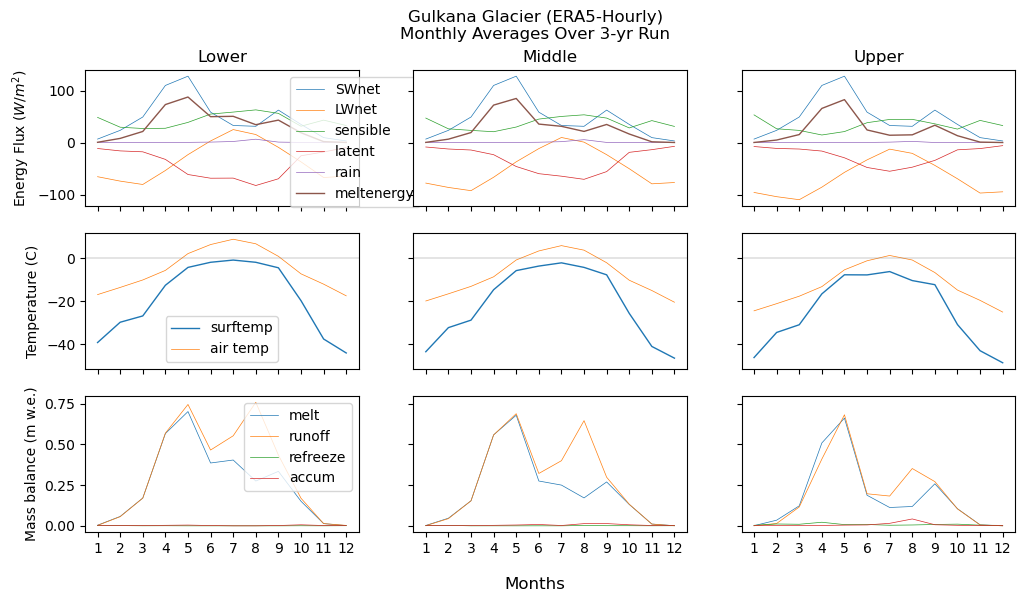

In [9]:
file = '/home/claire/research/Output/EB/run_2023_06_27_hourly_00.nc'
freq = 'd'
bin = 1
airtemp = np.zeros((3,12))
for b in range(3):
    climatedf = xr.open_dataset('/home/claire/research/Output/EB/climateds.nc').isel(bin=b).to_pandas()
    monthly = climatedf['bin_temp'].resample('M').mean()
    monthly_avg = np.mean(monthly[:(nyr*12)].values.reshape((nyr,12)),axis=0)
    airtemp[b,:] = monthly_avg

plot_avgs(file,nyr,airtemp)

In [57]:
fp = '/home/claire/research/PyGEM/pygem_eb/sample_init_data/endaccum_initialTp.nc'
ds = xr.open_dataset(fp)
print(ds.firn_depth)

<xarray.DataArray 'firn_depth' (bin_elev: 3)>
array([0, 0, 2])
Coordinates:
  * bin_elev  (bin_elev) float64 1.134e+03 1.381e+03 1.741e+03


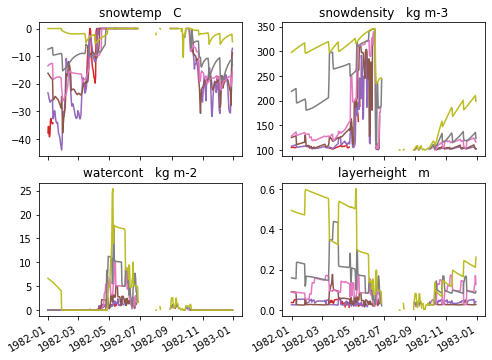

In [59]:

# plot_layers(file,freq,bin)
plot_layers(file,freq,bin,2)

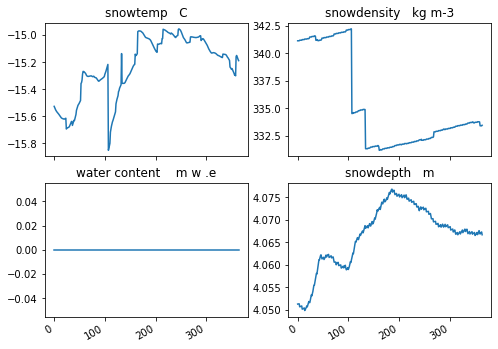

In [55]:
plot_avg_layers(file,freq,bin,nyr)

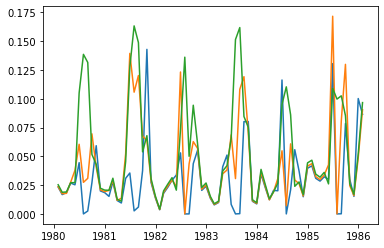

In [63]:
ds = xr.open_dataset(file)
accum = ds['accum'].to_pandas()
accum = accum.resample('M').mean()*1000
plt.plot(accum.index,accum)
plt.show()

In [107]:
import xarray as xr
ds = xr.open_dataset('/home/claire/research/climate_data/ERA5/ERA5_hourly/ERA5_precip_hourly.nc')
print(np.mean(ds['tp'].values),np.max(ds['tp'].values))
print(np.sum(ds['tp'].values[:8790]))

9.609282174515584e-05 0.004886787384748459
